In [1]:
import pandas as pd
import numpy as np
import os
from IPython.display import display
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


In [2]:
import numpy as np
from pathlib import Path

def incarca_npy_ca_variabile(folder_path):
    folder = Path(folder_path)
    
    for file_path in folder.glob('*.npy'):
        # Luăm numele fișierului fără ".npy"
        nume_baza = file_path.stem 
        
        # 1. Înlocuim cratimele și spațiile cu underscore (_) ca să fie valid în Python
        nume_variabila = nume_baza.replace('-', '_').replace(' ', '_')
        
        # 2. Dacă numele începe cu o cifră (ex: 2026...), îi punem un "v_" în față
        if nume_variabila[0].isdigit():
            nume_variabila = f"v_{nume_variabila}"
            
        # 3. Creăm variabila direct în mediul global!
        globals()[nume_variabila] = np.load(file_path)
        
        print(f"Gata! Am creat variabila: {nume_variabila}")

# --- CUM O FOLOSEȘTI ---
incarca_npy_ca_variabile('/Users/adaciortan/Desktop/experiment data/daca ai fii un stick/the column')

# DUPĂ CE RULEZI FUNCȚIA, POȚI SCRIE DIRECT:
# print(v_2026_02_25_h2_400bar_SRB_volume_1)

Gata! Am creat variabila: v_2026_02_25_h2_400bar_SRB_volume_1
Gata! Am creat variabila: v_2026_02_25_h2_400bar_SRB_time
Gata! Am creat variabila: v_2025_07_01_h2_100bar_SRB_volume_1
Gata! Am creat variabila: v_2026_02_25_h2_400bar_SRB_volume_2
Gata! Am creat variabila: v_2025_07_01_h2_100bar_SRB_volume_2
Gata! Am creat variabila: v_2026_04_02_h2_200bar_SRB_time
Gata! Am creat variabila: v_2026_02_10_h2_200bar_SRB_volume_2
Gata! Am creat variabila: v_2026_02_10_h2_200bar_SRB_volume_1
Gata! Am creat variabila: v_2026_02_10_h2_200bar_SRB_time
Gata! Am creat variabila: v_2025_07_01_h2_100bar_SRB_time
Gata! Am creat variabila: v_2025_10_23_h2_60bar_SRB_volume_2
Gata! Am creat variabila: v_2026_04_02_h2_200bar_SRB_volume_2
Gata! Am creat variabila: v_2025_10_23_h2_60bar_SRB_volume_1
Gata! Am creat variabila: v_2026_04_02_h2_200bar_SRB_volume_1
Gata! Am creat variabila: v_2026_03_12_h2_200bar_SRB_time
Gata! Am creat variabila: v_2025_06_18_h2_100bar_SRB_volume_2
Gata! Am creat variabila: v_20

In [3]:
import numpy as np

def trim_and_normalize_set(time_arr, vol1_arr, vol2_arr):
    """
    Sincronizează și normalizează un set de 3 array-uri bazat pe minimul din Volum 1.
    """
    # 1. Găsim indexul valorii minime din Volum 1
    min_idx = np.argmin(vol1_arr)
    
    # 2. Tăiem toate cele 3 array-uri de la acel index până la final
    t_trim = time_arr[min_idx:]
    v1_trim = vol1_arr[min_idx:]
    v2_trim = vol2_arr[min_idx:]
    
    # 3. Scădem valoarea minimă din fiecare array tăiat ca să înceapă de la 0
    # Folosim np.min() pentru a ne asigura că cel mai mic punct devine exact 0.0
    t_norm = t_trim - np.min(t_trim)
    v1_norm = v1_trim - np.min(v1_trim)
    v2_norm = v2_trim - np.min(v2_trim)
    
    return t_norm, v1_norm, v2_norm

In [4]:
# 1. Experiment 25 Feb 2026 (400 bar)
time_26_02_25_clean, vol1_26_02_25_clean, vol2_26_02_25_clean = trim_and_normalize_set(
    v_2026_02_25_h2_400bar_SRB_time, 
    v_2026_02_25_h2_400bar_SRB_volume_1, 
    v_2026_02_25_h2_400bar_SRB_volume_2
)

# 2. Experiment 01 Iul 2025 (100 bar)
time_25_07_01_clean, vol1_25_07_01_clean, vol2_25_07_01_clean = trim_and_normalize_set(
    v_2025_07_01_h2_100bar_SRB_time, 
    v_2025_07_01_h2_100bar_SRB_volume_1, 
    v_2025_07_01_h2_100bar_SRB_volume_2
)

# 3. Experiment 10 Feb 2026 (200 bar)
time_26_02_10_clean, vol1_26_02_10_clean, vol2_26_02_10_clean = trim_and_normalize_set(
    v_2026_02_10_h2_200bar_SRB_time, 
    v_2026_02_10_h2_200bar_SRB_volume_1, 
    v_2026_02_10_h2_200bar_SRB_volume_2
)

# 4. Experiment 23 Oct 2025 (60 bar)
time_25_10_23_clean, vol1_25_10_23_clean, vol2_25_10_23_clean = trim_and_normalize_set(
    v_2025_10_23_h2_60bar_SRB_time, 
    v_2025_10_23_h2_60bar_SRB_volume_1, 
    v_2025_10_23_h2_60bar_SRB_volume_2
)

# 5. Experiment 18 Iun 2025 (100 bar)
time_25_06_18_clean, vol1_25_06_18_clean, vol2_25_06_18_clean = trim_and_normalize_set(
    v_2025_06_18_h2_100bar_SRB_time, 
    v_2025_06_18_h2_100bar_SRB_volume_1, 
    v_2025_06_18_h2_100bar_SRB_volume_2
)

# 6. Experiment 29 Ian 2026 (400 bar)
# Conversie timp din zile în minute
v_2026_01_29_h2_400bar_SRB_time_min = v_2026_01_29_h2_400bar_SRB_time * 24 * 60
time_26_01_29_clean, vol1_26_01_29_clean, vol2_26_01_29_clean = trim_and_normalize_set(
    v_2026_01_29_h2_400bar_SRB_time_min, 
    v_2026_01_29_h2_400bar_SRB_volume_1, 
    v_2026_01_29_h2_400bar_SRB_volume_2
)

# 7. Experiment 11 Nov 2025 (200 bar)
v_2025_11_11_h2_200bar_SRB_time_gen = np.arange(0, 18324)
time_25_11_11_clean, vol1_25_11_11_clean, vol2_25_11_11_clean = trim_and_normalize_set(
    v_2025_11_11_h2_200bar_SRB_time_gen, 
    v_2025_11_11_h2_200bar_SRB_volume_1, 
    v_2025_11_11_h2_200bar_SRB_volume_2
)

# 8. Experiment 12 Mar 2026 (200 bar)
time_26_03_12_clean, vol1_26_03_12_clean, vol2_26_03_12_clean = trim_and_normalize_set(
    v_2026_03_12_h2_200bar_SRB_time, 
    v_2026_03_12_h2_200bar_SRB_volume_1, 
    v_2026_03_12_h2_200bar_SRB_volume_2
)

# 9. Experiment 02 Apr 2026 (200 bar) - Menționat în log-ul tău de variabile
time_26_04_02_clean, vol1_26_04_02_clean, vol2_26_04_02_clean = trim_and_normalize_set(
    v_2026_04_02_h2_200bar_SRB_time, 
    v_2026_04_02_h2_200bar_SRB_volume_1, 
    v_2026_04_02_h2_200bar_SRB_volume_2
)

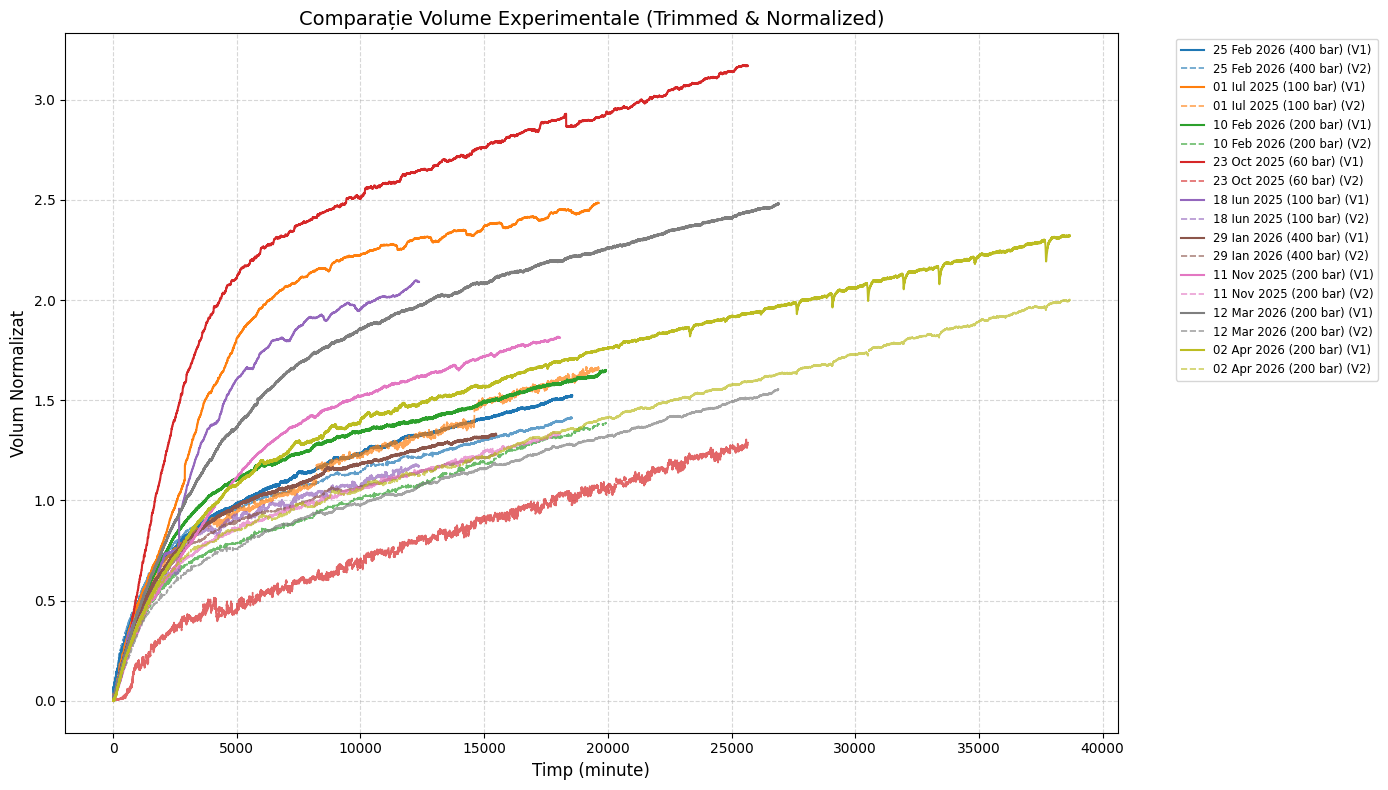

In [5]:
import matplotlib.pyplot as plt

def plot_all_experiments():
    plt.figure(figsize=(14, 8))
    
    # Lista de experimente bazată pe variabilele create anterior
    experiments = [
        ("25 Feb 2026 (400 bar)", time_26_02_25_clean, vol1_26_02_25_clean, vol2_26_02_25_clean),
        ("01 Iul 2025 (100 bar)", time_25_07_01_clean, vol1_25_07_01_clean, vol2_25_07_01_clean),
        ("10 Feb 2026 (200 bar)", time_26_02_10_clean, vol1_26_02_10_clean, vol2_26_02_10_clean),
        ("23 Oct 2025 (60 bar)", time_25_10_23_clean, vol1_25_10_23_clean, vol2_25_10_23_clean),
        ("18 Iun 2025 (100 bar)", time_25_06_18_clean, vol1_25_06_18_clean, vol2_25_06_18_clean),
        ("29 Ian 2026 (400 bar)", time_26_01_29_clean, vol1_26_01_29_clean, vol2_26_01_29_clean),
        ("11 Nov 2025 (200 bar)", time_25_11_11_clean, vol1_25_11_11_clean, vol2_25_11_11_clean),
        ("12 Mar 2026 (200 bar)", time_26_03_12_clean, vol1_26_03_12_clean, vol2_26_03_12_clean),
        ("02 Apr 2026 (200 bar)", time_26_04_02_clean, vol1_26_04_02_clean, vol2_26_04_02_clean)
    ]

    for label, t, v1, v2 in experiments:
        line = plt.plot(t, v1, label=f"{label} (V1)", linewidth=1.5)
        color = line[0].get_color()
        plt.plot(t, v2, label=f"{label} (V2)", linestyle='--', color=color, alpha=0.7, linewidth=1.2)

    plt.title('Comparație Volume Experimentale (Trimmed & Normalized)', fontsize=14)
    plt.xlabel('Timp (minute)', fontsize=12)
    plt.ylabel('Volum Normalizat', fontsize=12)
    
    # Legendă plasată în exterior pentru a nu acoperi datele
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=1)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.show()

# Apelarea funcției pentru afișare
plot_all_experiments()

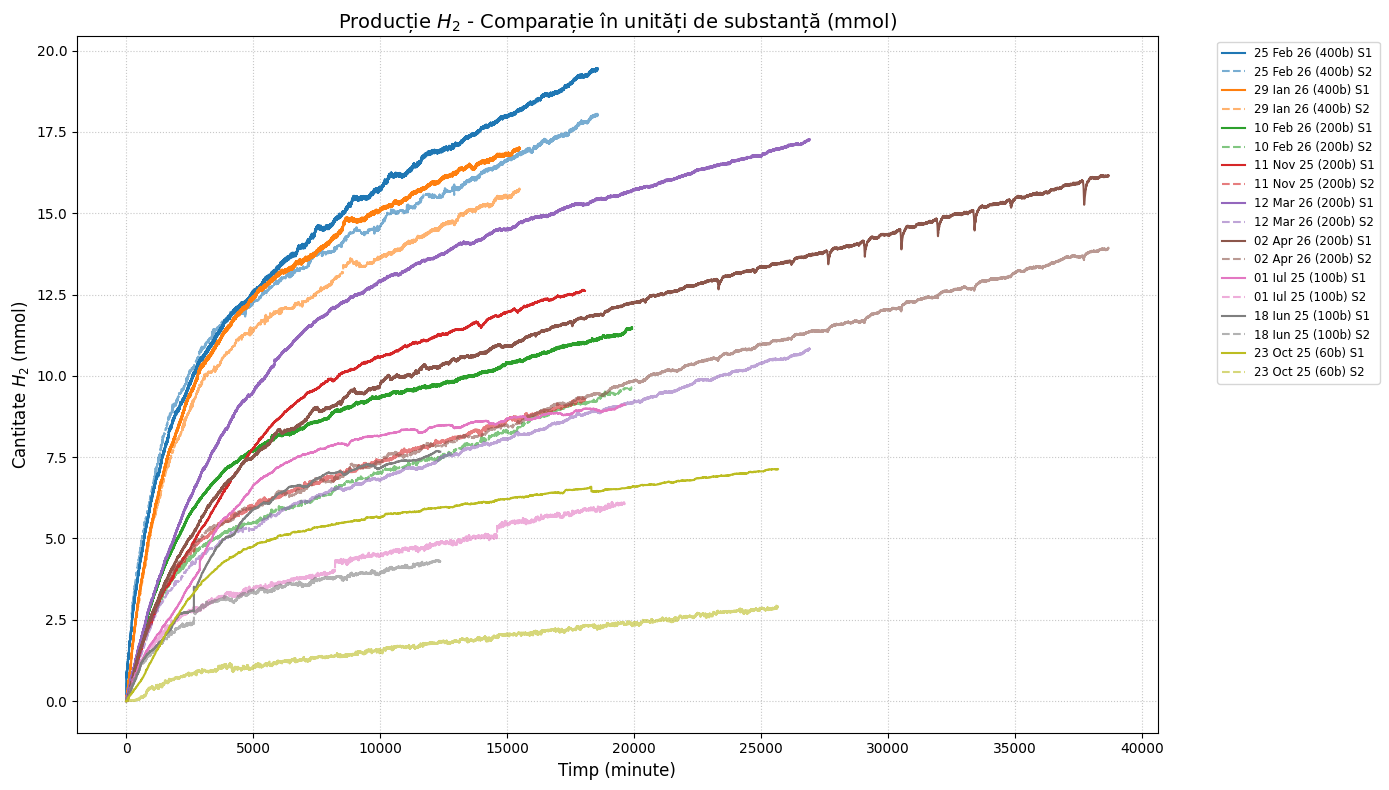

In [6]:
def convert_ml_to_mmol(volume_array_ml, pressure_bar):
    """
    Transformă un array de volume din ml în mmol de H2,
    ținând cont de densitatea specifică presiunii.
    """
    molar_mass_h2 = 2.016 # Masa molară a H2 în g/mol (sau mg/mmol)
    
    if pressure_bar == 100:
        density = 7.392   # kg/m^3 (echivalent cu g/L)
    elif pressure_bar == 200:
        density = 14.030
    elif pressure_bar == 400:
        density = 25.743
    elif pressure_bar == 60:
        density = 4.534
    else:
        raise ValueError("Presiune necunoscută. Te rog alege 100, 200 sau 400.")
        
    # Calcul: (Volum * Densitate) / Masa Molară
    return volume_array_ml * (density / molar_mass_h2)
# --- Conversie în mmol pentru toate experimentele ---

# 400 bar
mmol1_26_02_25 = convert_ml_to_mmol(vol1_26_02_25_clean, 400)
mmol2_26_02_25 = convert_ml_to_mmol(vol2_26_02_25_clean, 400)

mmol1_26_01_29 = convert_ml_to_mmol(vol1_26_01_29_clean, 400)
mmol2_26_01_29 = convert_ml_to_mmol(vol2_26_01_29_clean, 400)

# 200 bar
mmol1_26_02_10 = convert_ml_to_mmol(vol1_26_02_10_clean, 200)
mmol2_26_02_10 = convert_ml_to_mmol(vol2_26_02_10_clean, 200)

mmol1_25_11_11 = convert_ml_to_mmol(vol1_25_11_11_clean, 200)
mmol2_25_11_11 = convert_ml_to_mmol(vol2_25_11_11_clean, 200)

mmol1_26_03_12 = convert_ml_to_mmol(vol1_26_03_12_clean, 200)
mmol2_26_03_12 = convert_ml_to_mmol(vol2_26_03_12_clean, 200)

mmol1_26_04_02 = convert_ml_to_mmol(vol1_26_04_02_clean, 200)
mmol2_26_04_02 = convert_ml_to_mmol(vol2_26_04_02_clean, 200)

# 100 bar
mmol1_25_07_01 = convert_ml_to_mmol(vol1_25_07_01_clean, 100)
mmol2_25_07_01 = convert_ml_to_mmol(vol2_25_07_01_clean, 100)

mmol1_25_06_18 = convert_ml_to_mmol(vol1_25_06_18_clean, 100)
mmol2_25_06_18 = convert_ml_to_mmol(vol2_25_06_18_clean, 100)

# 60 bar
mmol1_25_10_23 = convert_ml_to_mmol(vol1_25_10_23_clean, 60)
mmol2_25_10_23 = convert_ml_to_mmol(vol2_25_10_23_clean, 60)

# --- Vizualizare Date în mmol ---

def plot_mmol_comparison():
    plt.figure(figsize=(14, 8))
    
    data_to_plot = [
        ("25 Feb 26 (400b)", time_26_02_25_clean, mmol1_26_02_25, mmol2_26_02_25),
        ("29 Ian 26 (400b)", time_26_01_29_clean, mmol1_26_01_29, mmol2_26_01_29),
        ("10 Feb 26 (200b)", time_26_02_10_clean, mmol1_26_02_10, mmol2_26_02_10),
        ("11 Nov 25 (200b)", time_25_11_11_clean, mmol1_25_11_11, mmol2_25_11_11),
        ("12 Mar 26 (200b)", time_26_03_12_clean, mmol1_26_03_12, mmol2_26_03_12),
        ("02 Apr 26 (200b)", time_26_04_02_clean, mmol1_26_04_02, mmol2_26_04_02),
        ("01 Iul 25 (100b)", time_25_07_01_clean, mmol1_25_07_01, mmol2_25_07_01),
        ("18 Iun 25 (100b)", time_25_06_18_clean, mmol1_25_06_18, mmol2_25_06_18),
        ("23 Oct 25 (60b)",  time_25_10_23_clean, mmol1_25_10_23, mmol2_25_10_23)
    ]

    for label, t, m1, m2 in data_to_plot:
        p = plt.plot(t, m1, label=f"{label} S1", linewidth=1.5)
        plt.plot(t, m2, label=f"{label} S2", linestyle='--', color=p[0].get_color(), alpha=0.6)

    plt.title('Producție $H_2$ - Comparație în unități de substanță (mmol)', fontsize=14)
    plt.xlabel('Timp (minute)', fontsize=12)
    plt.ylabel('Cantitate $H_2$ (mmol)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_mmol_comparison()

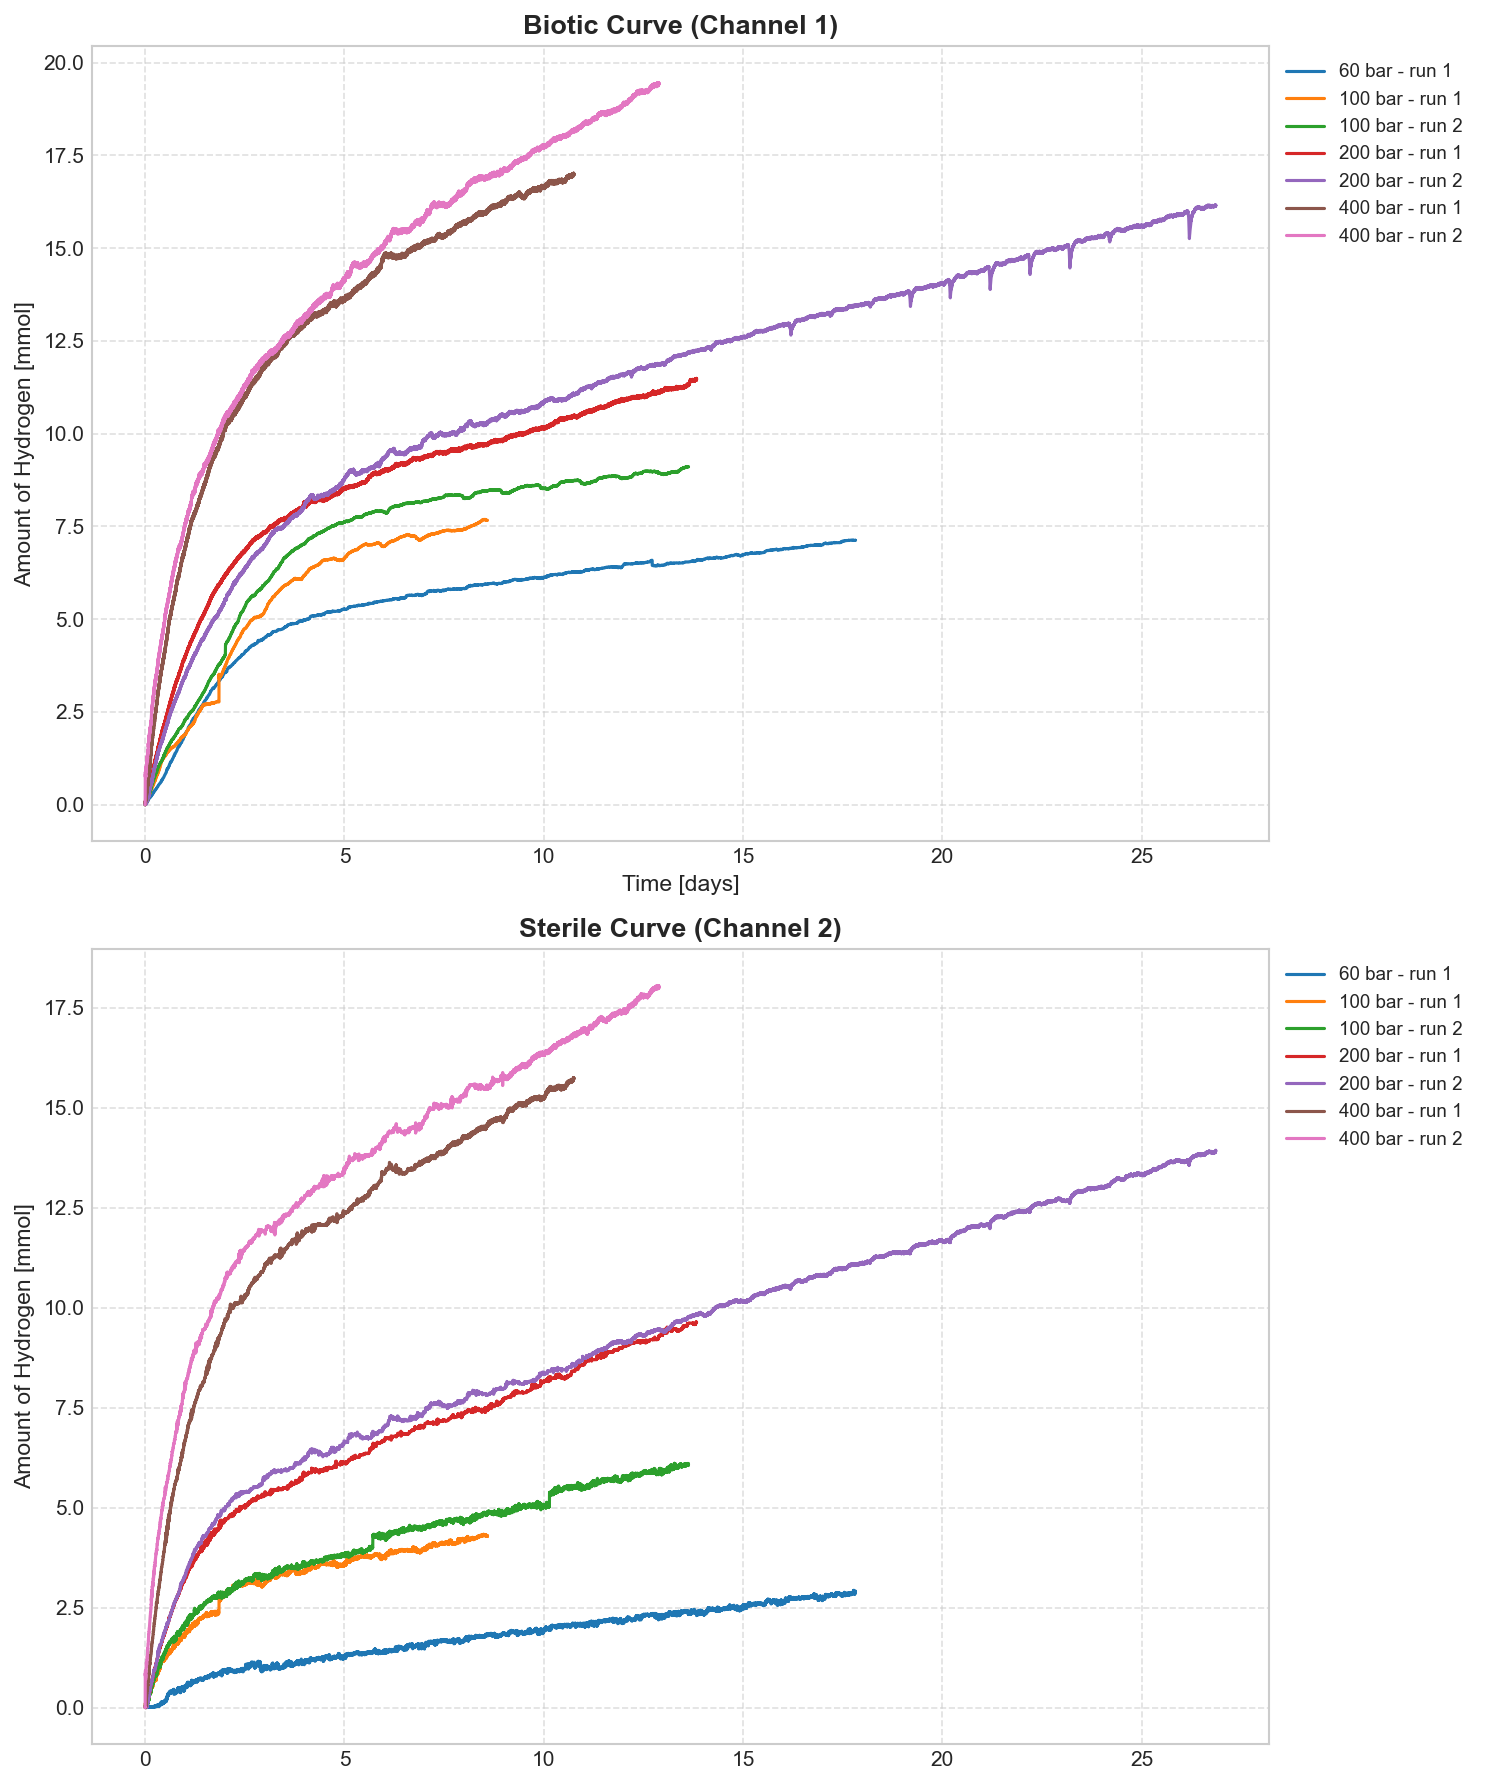

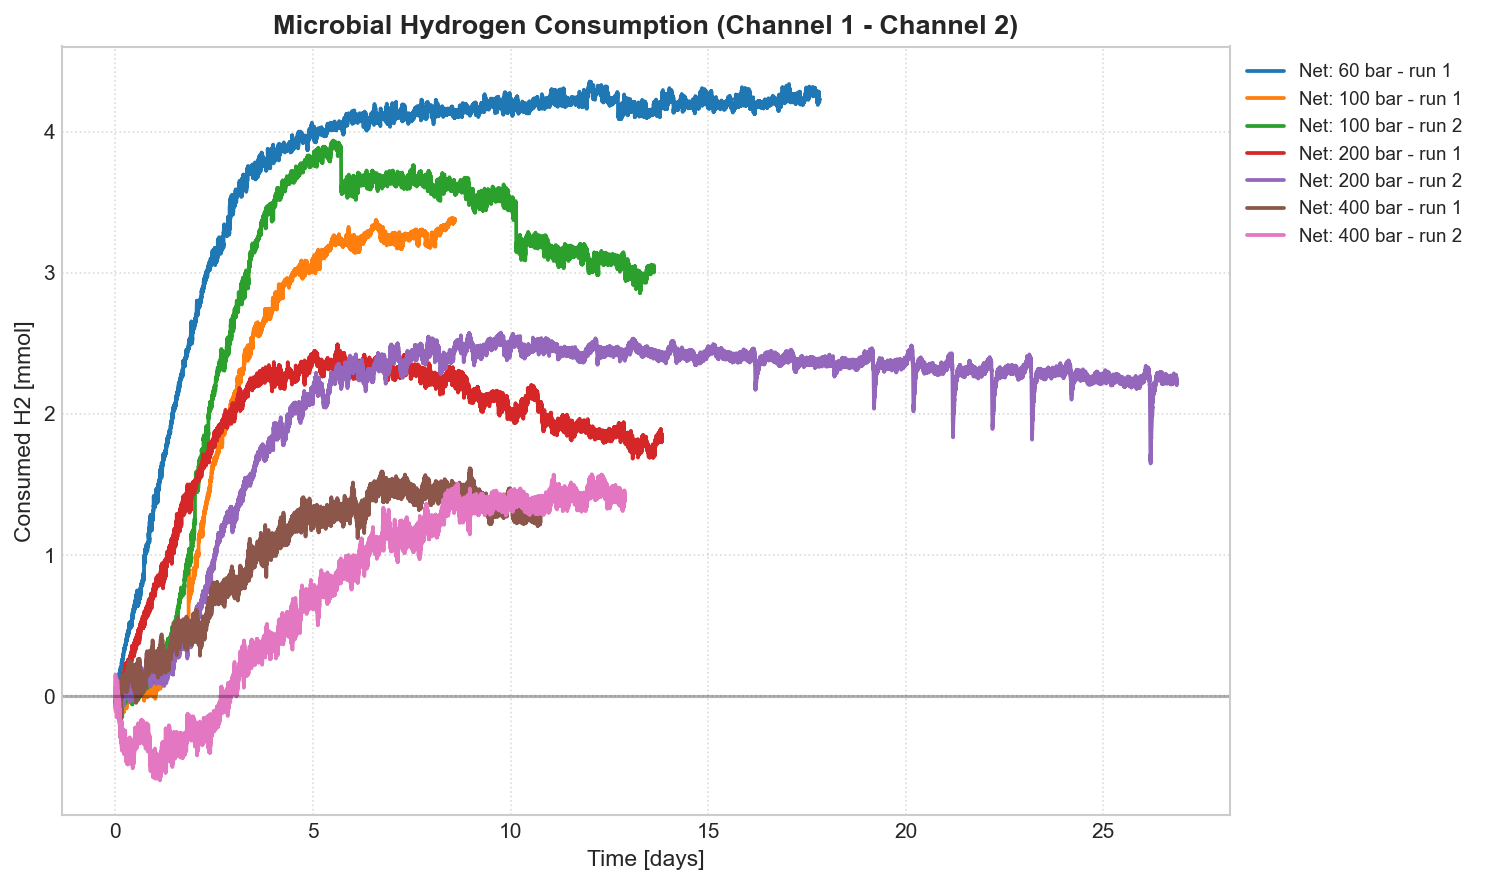

In [15]:
import matplotlib.pyplot as plt

# Organizăm datele pentru un loop eficient
all_data = [
    ("60 bar - run 1",  time_25_10_23_clean, mmol1_25_10_23, mmol2_25_10_23),
    ("100 bar - run 1", time_25_06_18_clean, mmol1_25_06_18, mmol2_25_06_18),
    ("100 bar - run 2", time_25_07_01_clean, mmol1_25_07_01, mmol2_25_07_01),
    ("200 bar - run 1", time_26_02_10_clean, mmol1_26_02_10, mmol2_26_02_10),
    ("200 bar - run 2", time_26_04_02_clean, mmol1_26_04_02, mmol2_26_04_02),
    ("400 bar - run 1", time_26_01_29_clean, mmol1_26_01_29, mmol2_26_01_29),
    ("400 bar - run 2", time_26_02_25_clean, mmol1_26_02_25, mmol2_26_02_25)
]

# Convertim timpul din minute în zile (1 zi = 1440 min)
all_data = [(label, t / 1440.0, m1, m2) for label, t, m1, m2 in all_data]

# Setări globale de stil
plt.rcParams.update({'font.size': 10})

# --- FIGURA 1: Sterile vs Microbial (Individuale) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

for label, t, m1, m2 in all_data:

    ax1.plot(t, m1, label=label, linewidth=1.5)
    ax2.plot(t, m2, label=label, linewidth=1.5)

ax2.set_title("Sterile Curve (Channel 2)")
ax2.set_ylabel("Amount of Hydrogen [mmol]")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))

ax1.set_title("Biotic Curve (Channel 1)")
ax1.set_ylabel("Amount of Hydrogen [mmol]")
ax1.set_xlabel("Time [days]")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

# --- FIGURA 2: Net Consumption ---
plt.figure(figsize=(10, 6))

for label, t, m1, m2 in all_data:
    # Plotăm doar dacă există o diferență relevantă (sau toate, cum preferi)
    plt.plot(t, m1 - m2, label=f"Net: {label}", linewidth=1.8)

plt.axhline(0, color='black', linestyle='-', alpha=0.3)  # Linie de referință la zero
plt.title("Microbial Hydrogen Consumption (Channel 1 - Channel 2)")
plt.xlabel("Time [days]")
plt.ylabel("Consumed H2 [mmol]")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os

# ─────────────────────────────────────────────────────────────────
# YOUR DATA VARIABLES (plug in your actual arrays here)
# ─────────────────────────────────────────────────────────────────
# Replace these with your actual time/mmol arrays:
# time_26_02_25_clean, mmol1_26_02_25, mmol2_26_02_25, etc.

# ─────────────────────────────────────────────────────────────────
# DATA REGISTRY — group experiments by pressure
# ─────────────────────────────────────────────────────────────────
pressure_groups = {
    "400 bar": [
        ("25 Feb 2026", time_26_02_25_clean, mmol1_26_02_25, mmol2_26_02_25),
        ("29 Ian 2026", time_26_01_29_clean, mmol1_26_01_29, mmol2_26_01_29),
    ],
    "200 bar": [
        ("10 Feb 2026", time_26_02_10_clean, mmol1_26_02_10, mmol2_26_02_10),
        ("02 Apr 2026", time_26_04_02_clean, mmol1_26_04_02, mmol2_26_04_02),
    ],
    "100 bar": [
        ("01 Iul 2025", time_25_07_01_clean, mmol1_25_07_01, mmol2_25_07_01),
        ("18 Iun 2025", time_25_06_18_clean, mmol1_25_06_18, mmol2_25_06_18),
    ],
    "60 bar": [
        ("23 Oct 2025", time_25_10_23_clean, mmol1_25_10_23, mmol2_25_10_23),
    ],
}

# ─────────────────────────────────────────────────────────────────
# STYLE SETTINGS
# ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.dpi": 150,
})

PLOT_TYPES = [
    ("Microbial",   "mmol1",       "Microbial curves ({pressure})",   "Amount H₂ [mmol]"),
    ("Sterile",     "mmol2",       "Sterile curves ({pressure})",     "Amount H₂ [mmol]"),
    ("Difference",  "mmol1-mmol2", "Difference curves ({pressure})",  "Consumed H₂ [mmol]"),
]

OUTPUT_ROOT = "H2_plots"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

# ─────────────────────────────────────────────────────────────────
# HELPER: pick a color palette for N curves
# ─────────────────────────────────────────────────────────────────
def get_colors(n, cmap_name="tab10"):
    cmap = cm.get_cmap(cmap_name)
    return [cmap(i / max(n - 1, 1)) for i in range(n)]


# ─────────────────────────────────────────────────────────────────
# HELPER: save one figure
# ─────────────────────────────────────────────────────────────────
def save_fig(fig, path):
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.close(fig)
    print(f"  Saved → {path}")


# ─────────────────────────────────────────────────────────────────
# 1.  PER-PRESSURE PLOTS
# ─────────────────────────────────────────────────────────────────
for pressure, experiments in pressure_groups.items():
    # Folder name: "400_bar", "200_bar", etc.
    folder_name = pressure.replace(" ", "_")
    folder_path = os.path.join(OUTPUT_ROOT, folder_name)
    os.makedirs(folder_path, exist_ok=True)

    print(f"\n── {pressure} ──")
    colors = get_colors(len(experiments))

    for plot_type, data_key, title_template, ylabel in PLOT_TYPES:
        title = title_template.format(pressure=pressure)
        fig, ax = plt.subplots(figsize=(9, 5))

        for (exp_label, t, m1, m2), color in zip(experiments, colors):
            if data_key == "mmol1":
                y = m1
            elif data_key == "mmol2":
                y = m2
            else:  # mmol1-mmol2
                y = m1 - m2

            ax.plot(t, y, label=exp_label, color=color, linewidth=1.8)

        if data_key == "mmol1-mmol2":
            ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.4)

        ax.set_title(title)
        ax.set_xlabel("Time [minutes]")
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)

        filename = f"{plot_type}_{folder_name}.png"
        save_fig(fig, os.path.join(folder_path, filename))


# ─────────────────────────────────────────────────────────────────
# 2.  COMBINED PLOTS — all pressures together
# ─────────────────────────────────────────────────────────────────
combined_folder = os.path.join(OUTPUT_ROOT, "All_pressures_combined")
os.makedirs(combined_folder, exist_ok=True)
print("\n── All pressures combined ──")

# Flatten: (label_with_pressure, t, m1, m2)
all_experiments = [
    (f"{exp_label} ({pressure})", t, m1, m2)
    for pressure, experiments in pressure_groups.items()
    for (exp_label, t, m1, m2) in experiments
]
colors_all = get_colors(len(all_experiments), cmap_name="tab20")

for plot_type, data_key, title_template, ylabel in PLOT_TYPES:
    title = title_template.format(pressure="All Pressures")
    fig, ax = plt.subplots(figsize=(11, 6))

    for (exp_label, t, m1, m2), color in zip(all_experiments, colors_all):
        if data_key == "mmol1":
            y = m1
        elif data_key == "mmol2":
            y = m2
        else:
            y = m1 - m2

        ax.plot(t, y, label=exp_label, color=color, linewidth=1.6)

    if data_key == "mmol1-mmol2":
        ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.4)

    ax.set_title(title)
    ax.set_xlabel("Time [minutes]")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0,
              fontsize=8)

    filename = f"{plot_type}_All_pressures.png"
    save_fig(fig, os.path.join(combined_folder, filename))

print("\n✓ All plots saved to:", OUTPUT_ROOT)


── 400 bar ──
  Saved → H2_plots/400_bar/Microbial_400_bar.png


/var/folders/5z/hkz232rd2_n78cjbyj1g9t_40000gn/T/ipykernel_36852/993447976.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/5z/hkz232rd2_n78cjbyj1g9t_40000gn/T/ipykernel_36852/993447976.py:66: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(path, bbox_inches="tight", dpi=150)


  Saved → H2_plots/400_bar/Sterile_400_bar.png
  Saved → H2_plots/400_bar/Difference_400_bar.png

── 200 bar ──
  Saved → H2_plots/200_bar/Microbial_200_bar.png
  Saved → H2_plots/200_bar/Sterile_200_bar.png
  Saved → H2_plots/200_bar/Difference_200_bar.png

── 100 bar ──
  Saved → H2_plots/100_bar/Microbial_100_bar.png
  Saved → H2_plots/100_bar/Sterile_100_bar.png
  Saved → H2_plots/100_bar/Difference_100_bar.png

── 60 bar ──
  Saved → H2_plots/60_bar/Microbial_60_bar.png
  Saved → H2_plots/60_bar/Sterile_60_bar.png
  Saved → H2_plots/60_bar/Difference_60_bar.png

── All pressures combined ──
  Saved → H2_plots/All_pressures_combined/Microbial_All_pressures.png
  Saved → H2_plots/All_pressures_combined/Sterile_All_pressures.png
  Saved → H2_plots/All_pressures_combined/Difference_All_pressures.png

✓ All plots saved to: H2_plots


NameError: name 'mmol1' is not defined

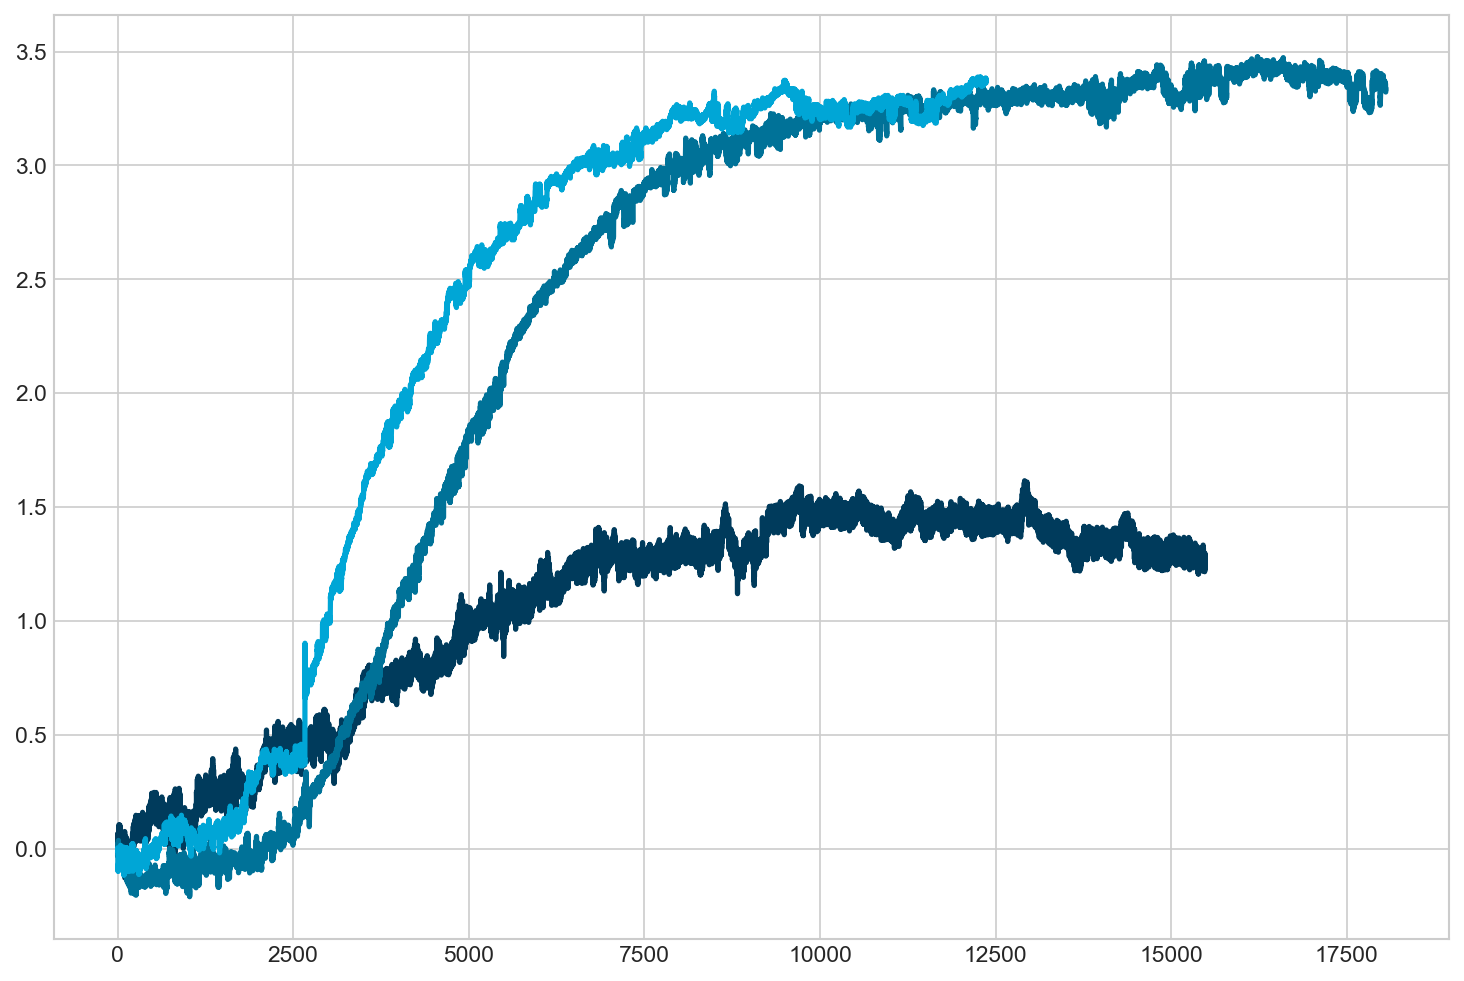

In [9]:

import matplotlib.pyplot as plt

# 1. Use a built-in style as a clean foundation
plt.style.use('seaborn-v0_8-whitegrid') 

# 2. Setup the figure and axis (Object-Oriented approach)
fig, ax = plt.subplots(figsize=(12, 8))

# 3. Define a modern, colorblind-friendly hex palette
# Going from dark/cool to warm/bright to represent pressure changes
#colors = ['#264653', '#2A9D8F', '#E9C46A', '#E76F51'] 
# From deep navy to the poster's exact bright cyan, down to a light icy blue
colors = ['#003B5C', '#007298', '#00A6D6', '#80D2EB']

# 4. Plot the lines with increased thickness, custom colors, and rounded caps
ax.plot(time_26_01_29_clean, mmol1_26_01_29 - mmol2_26_01_29, 
        label="400 bar", color=colors[0], linewidth=2.5, solid_capstyle='round')
ax.plot(time_25_11_11_clean, mmol1_25_11_11 - mmol2_25_11_11, 
        label="200 bar", color=colors[1], linewidth=2.5, solid_capstyle='round')
ax.plot(time_25_06_18_clean, mmol1_25_06_18 - mmol2_25_06_18, 
        label="100 bar", color=colors[2], linewidth=2.5, solid_capstyle='round')
ax.plot(time_25_10_23_clean, mmol1 - mmol2, 
        label="60 bar", color=colors[3], linewidth=2.5, solid_capstyle='round')

# 5. Upgrade the Typography
ax.set_title("Microbial Consumption Over Time", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Time [minutes]", fontsize=14, fontweight='500', labelpad=10)
ax.set_ylabel("Consumed Hydrogen [mmol]", fontsize=14, fontweight='500', labelpad=10)

# Increase tick label size for readability
ax.tick_params(axis='both', which='major', labelsize=12)

# 6. Clean up the Grid and Borders (Despining)
# Make the grid very subtle so it doesn't compete with the data lines
ax.grid(True, linestyle=':', linewidth=1.2, alpha=0.5)

# Remove the top and right borders for a cleaner, modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# 7. Style the Legend
legend = ax.legend(loc='upper left', fontsize=12, frameon=True, 
                   facecolor='white', edgecolor='none', shadow=True)

# Tight layout ensures nothing gets cut off when saving
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def trim_and_zero_from_minimum(time_array, value_array):
    """
    1. Găsește valoarea minimă.
    2. Taie array-urile de la acel punct (ignoră tot ce e înainte).
    3. Scade minimul din restul valorilor ca array-ul să înceapă de la 0.
    """
    # Ne asigurăm că lucrăm cu array-uri numpy
    time_array = np.asarray(time_array)
    value_array = np.asarray(value_array)
    
    # 1. Găsim poziția (indexul) și valoarea minimă
    min_index = np.argmin(value_array)
    min_value = value_array[min_index]
    
    # 2. Decupăm ambele array-uri de la acel index până la capăt
    trimmed_time = time_array[min_index:]
    trimmed_values = value_array[min_index:]
    
    # 3. Scădem valoarea minimă din întregul array tăiat
    # Deoarece prima valoare este chiar min_value, prima valoare devine automat 0
    zeroed_values = trimmed_values - min_value
    
    return trimmed_time, zeroed_values

# --- Exemplu de cum o folosești în codul tău ---

# time_trimmed, moles_consumed_zeroed = trim_and_zero_from_minimum(time, moles_consumed)

# Apoi bagi datele noi în fit_line:
# coeffs1, fitted_data1, line_equation1 = fit_line(time_trimmed, moles_consumed_zeroed, degree=2)


timp_nou, valori_noi = trim_and_zero_from_minimum(time, volume_2)
timp_nou2, valori_noi2 = trim_and_zero_from_minimum(time2, volume2)
# print("Timp tăiat:", timp_nou)       # Va afișa: [3, 4, 5]
# print("Valori tăiate:", valori_noi)   # Va afișa: [-2, 1, 4]


In [ ]:
print("Avem NaN-uri in moles_consumed?:", np.isnan(volume2).any())
print("Avem numere infinite in moles_consumed?:", np.isinf(volume2).any())

timp_nou= timp_nou *24*60

In [17]:
import numpy as np
import pandas as pd

def time_to_fraction(t_days, consumed, frac):
    """Time (days) from start until consumed reaches `frac` of the total rise
    (baseline -> peak), counting only upward progress. Negative-slope (downward)
    segments are flattened out with a running-maximum envelope, so dips never count."""
    t = np.asarray(t_days, float)
    y = np.asarray(consumed, float)
    i_peak = int(np.argmax(y))
    total = y[i_peak] - y[0]
    if total <= 0:
        return np.nan
    y_pos = np.maximum.accumulate(y[:i_peak + 1])   # positive-slope-only envelope
    target = y[0] + frac * total
    idx = int(np.argmax(y_pos >= target))
    if idx == 0:
        return 0.0
    y0, y1, t0, t1 = y_pos[idx-1], y_pos[idx], t[idx-1], t[idx]
    tc = t0 if y1 == y0 else t0 + (target - y0) * (t1 - t0) / (y1 - y0)
    return float(tc - t[0])
    

# (label, pressure, time[min], biotic mmol, sterile mmol) for every experiment
experiments = [
    ("25 Feb 2026", 400, time_26_02_25_clean, mmol1_26_02_25, mmol2_26_02_25),
    ("29 Jan 2026", 400, time_26_01_29_clean, mmol1_26_01_29, mmol2_26_01_29),
    ("10 Feb 2026", 200, time_26_02_10_clean, mmol1_26_02_10, mmol2_26_02_10),
    ("02 Apr 2026", 200, time_26_04_02_clean, mmol1_26_04_02, mmol2_26_04_02),
    ("01 Jul 2025", 100, time_25_07_01_clean, mmol1_25_07_01, mmol2_25_07_01),
    ("18 Jun 2025", 100, time_25_06_18_clean, mmol1_25_06_18, mmol2_25_06_18),
    ("23 Oct 2025",  60, time_25_10_23_clean, mmol1_25_10_23, mmol2_25_10_23),
]

rows = []
for label, P, t_min, m1, m2 in experiments:
    consumed = np.asarray(m1, float) - np.asarray(m2, float)   # biotic - sterile
    consumed = consumed - consumed[0]                          # start at zero
    t_days = np.asarray(t_min, float) / 1440.0                 # minutes -> days
    rows.append({
        "experiment": label,
        "pressure (bar)": P,
        "t to 5% (days)":  time_to_fraction(t_days, consumed, 0.05),
        "t to 90% (days)": time_to_fraction(t_days, consumed, 0.90),
    })

times_df = pd.DataFrame(rows)
display(times_df)

,experiment,pressure (bar),t to 5% (days),t to 90% (days)
0,25 Feb 2026,400,0.000891,8.352411
1,29 Jan 2026,400,0.001176,5.982626
2,10 Feb 2026,200,0.152903,3.417491
3,02 Apr 2026,200,0.298978,5.590929
4,01 Jul 2025,100,0.712931,4.049444
5,18 Jun 2025,100,1.113222,4.652986
6,23 Oct 2025,60,0.151024,4.261493


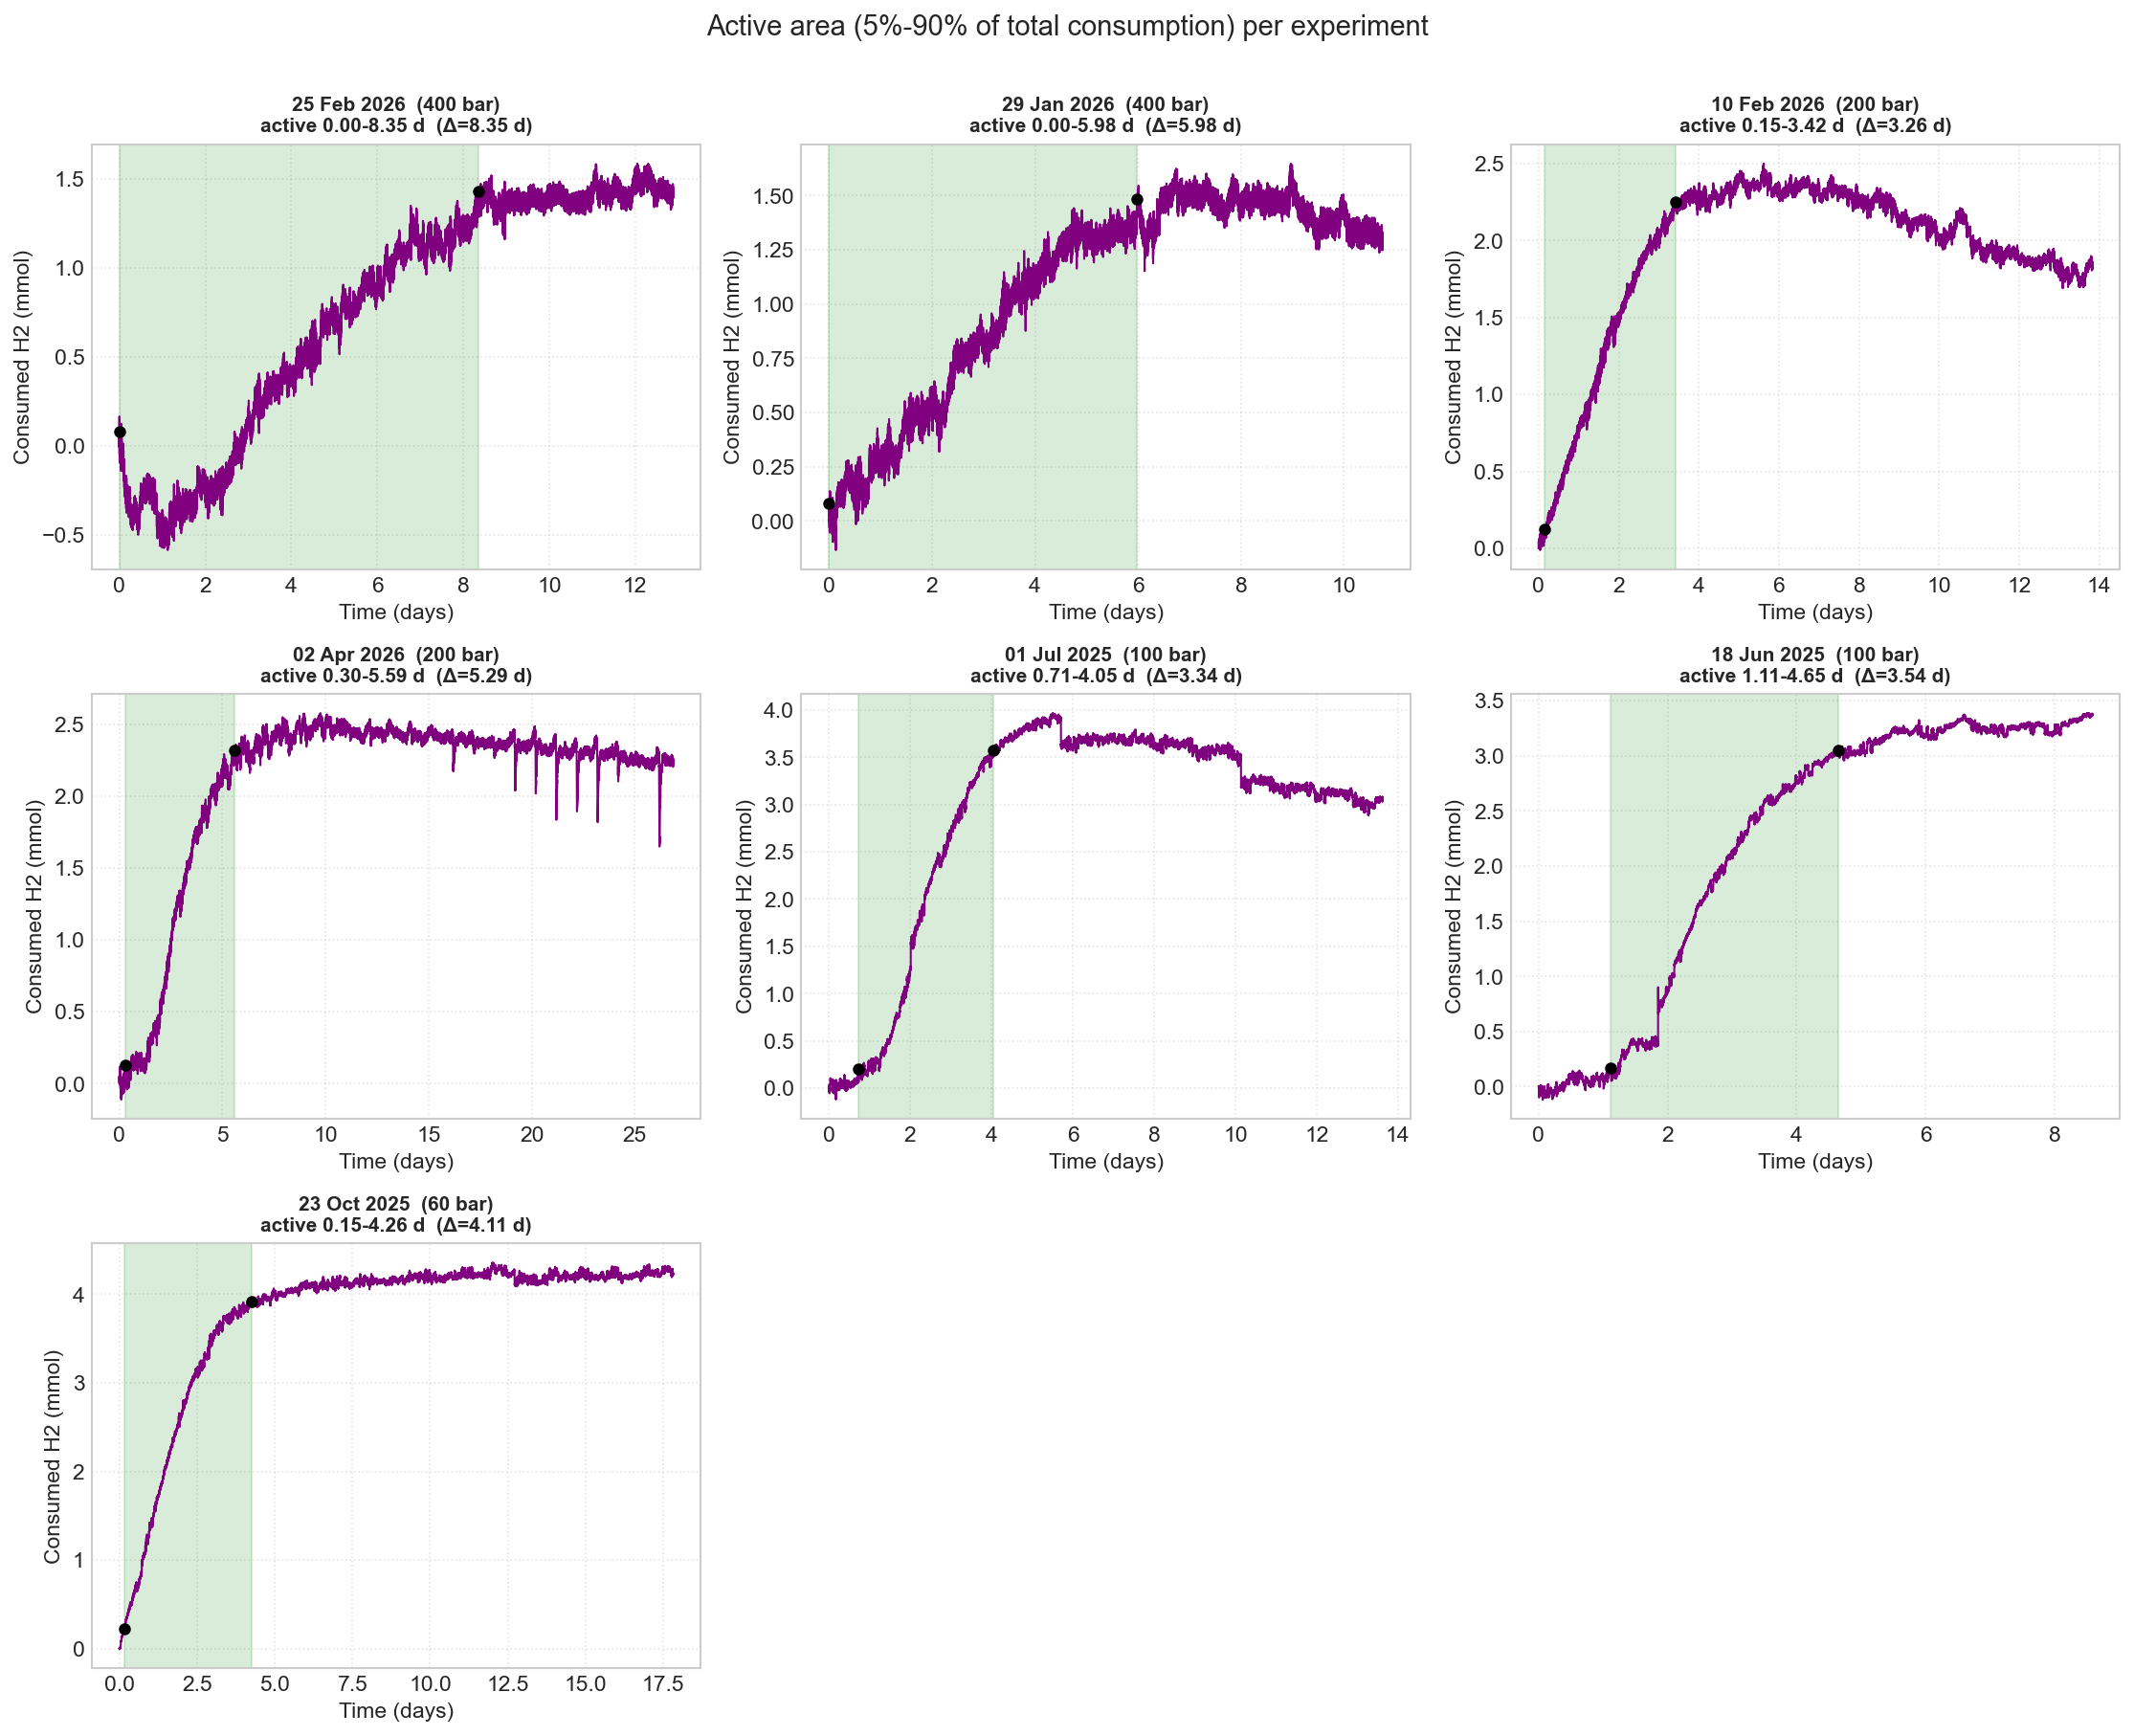

In [ ]:
import numpy as np
import pandas as pd

def time_to_fraction(t_days, consumed, frac):
    """Time (days) from start until consumed reaches `frac` of the total rise
    (baseline -> peak), counting only upward progress. Negative-slope (downward)
    segments are flattened out with a running-maximum envelope, so dips never count."""
    t = np.asarray(t_days, float)
    y = np.asarray(consumed, float)
    i_peak = int(np.argmax(y))
    total = y[i_peak] - y[0]
    if total <= 0:
        return np.nan
    y_pos = np.maximum.accumulate(y[:i_peak + 1])   # positive-slope-only envelope
    target = y[0] + frac * total
    idx = int(np.argmax(y_pos >= target))
    if idx == 0:
        return 0.0
    y0, y1, t0, t1 = y_pos[idx-1], y_pos[idx], t[idx-1], t[idx]
    tc = t0 if y1 == y0 else t0 + (target - y0) * (t1 - t0) / (y1 - y0)
    return float(tc - t[0])
    

# (label, pressure, time[min], biotic mmol, sterile mmol) for every experiment
experiments = [
    ("25 Feb 2026", 400, time_26_02_25_clean, mmol1_26_02_25, mmol2_26_02_25),
    ("29 Jan 2026", 400, time_26_01_29_clean, mmol1_26_01_29, mmol2_26_01_29),
    ("10 Feb 2026", 200, time_26_02_10_clean, mmol1_26_02_10, mmol2_26_02_10),
    ("02 Apr 2026", 200, time_26_04_02_clean, mmol1_26_04_02, mmol2_26_04_02),
    ("01 Jul 2025", 100, time_25_07_01_clean, mmol1_25_07_01, mmol2_25_07_01),
    ("18 Jun 2025", 100, time_25_06_18_clean, mmol1_25_06_18, mmol2_25_06_18),
    ("23 Oct 2025",  60, time_25_10_23_clean, mmol1_25_10_23, mmol2_25_10_23),
]

rows = []
for label, P, t_min, m1, m2 in experiments:
    consumed = np.asarray(m1, float) - np.asarray(m2, float)   # biotic - sterile
    consumed = consumed - consumed[0]                          # start at zero
    t_days = np.asarray(t_min, float) / 1440.0                 # minutes -> days
    rows.append({
        "experiment": label,
        "pressure (bar)": P,
        "t to 5% (days)":  time_to_fraction(t_days, consumed, 0.05),
        "t to 90% (days)": time_to_fraction(t_days, consumed, 0.90),
    })

times_df = pd.DataFrame(rows)
display(times_df)

def fraction_crossing(t_days, consumed, frac):
    t = np.asarray(t_days, float); y = np.asarray(consumed, float)
    i_peak = int(np.argmax(y)); total = y[i_peak] - y[0]
    if total <= 0:
        return np.nan, np.nan
    y_pos = np.maximum.accumulate(y[:i_peak + 1])    # positive-slope-only envelope
    target = y[0] + frac * total
    idx = int(np.argmax(y_pos >= target))
    if idx == 0:
        return float(t[0] - t[0]), float(y[0])
    y0, y1, t0, t1 = y_pos[idx-1], y_pos[idx], t[idx-1], t[idx]
    tc = t0 if y1 == y0 else t0 + (target - y0) * (t1 - t0) / (y1 - y0)
    return float(tc - t[0]), float(target)

ncols = 3
nrows = int(np.ceil(len(experiments) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for ax, (label, P, t_min, m1, m2) in zip(axes, experiments):
    consumed = np.asarray(m1, float) - np.asarray(m2, float)
    consumed = consumed - consumed[0]
    t_days = np.asarray(t_min, float) / 1440.0
    t5,  y5  = fraction_crossing(t_days, consumed, 0.05)
    t90, y90 = fraction_crossing(t_days, consumed, 0.90)

    ax.plot(t_days, consumed, color="purple", lw=1)
    if np.isfinite(t5) and np.isfinite(t90):
        ax.axvspan(t5, t90, color="green", alpha=0.15)
        ax.scatter([t5, t90], [y5, y90], color="black", zorder=5, s=25)
        ax.set_title(f"{label}  ({P} bar)\nactive {t5:.2f}-{t90:.2f} d  (Δ={t90-t5:.2f} d)", fontsize=10)
    else:
        ax.set_title(f"{label} ({P} bar) - no net consumption", fontsize=10)
    ax.set_xlabel("Time (days)"); ax.set_ylabel("Consumed H2 (mmol)")
    ax.grid(True, ls=":", alpha=0.5)

for ax in axes[len(experiments):]:   # hide unused panels
    ax.axis("off")
fig.suptitle("Active area (5%-90% of total consumption) per experiment", fontsize=14, y=1.005)
fig.tight_layout()
plt.show()

,experiment,pressure (bar),t to 5% (days),t to 90% (days)
0,25 Feb 2026,400,0.000462,6.869875
1,29 Jan 2026,400,0.001176,5.982626
2,10 Feb 2026,200,0.152903,3.417491
3,02 Apr 2026,200,0.298978,5.590929
4,01 Jul 2025,100,0.712931,4.049444
5,18 Jun 2025,100,1.113222,4.652986
6,23 Oct 2025,60,0.151024,4.261493


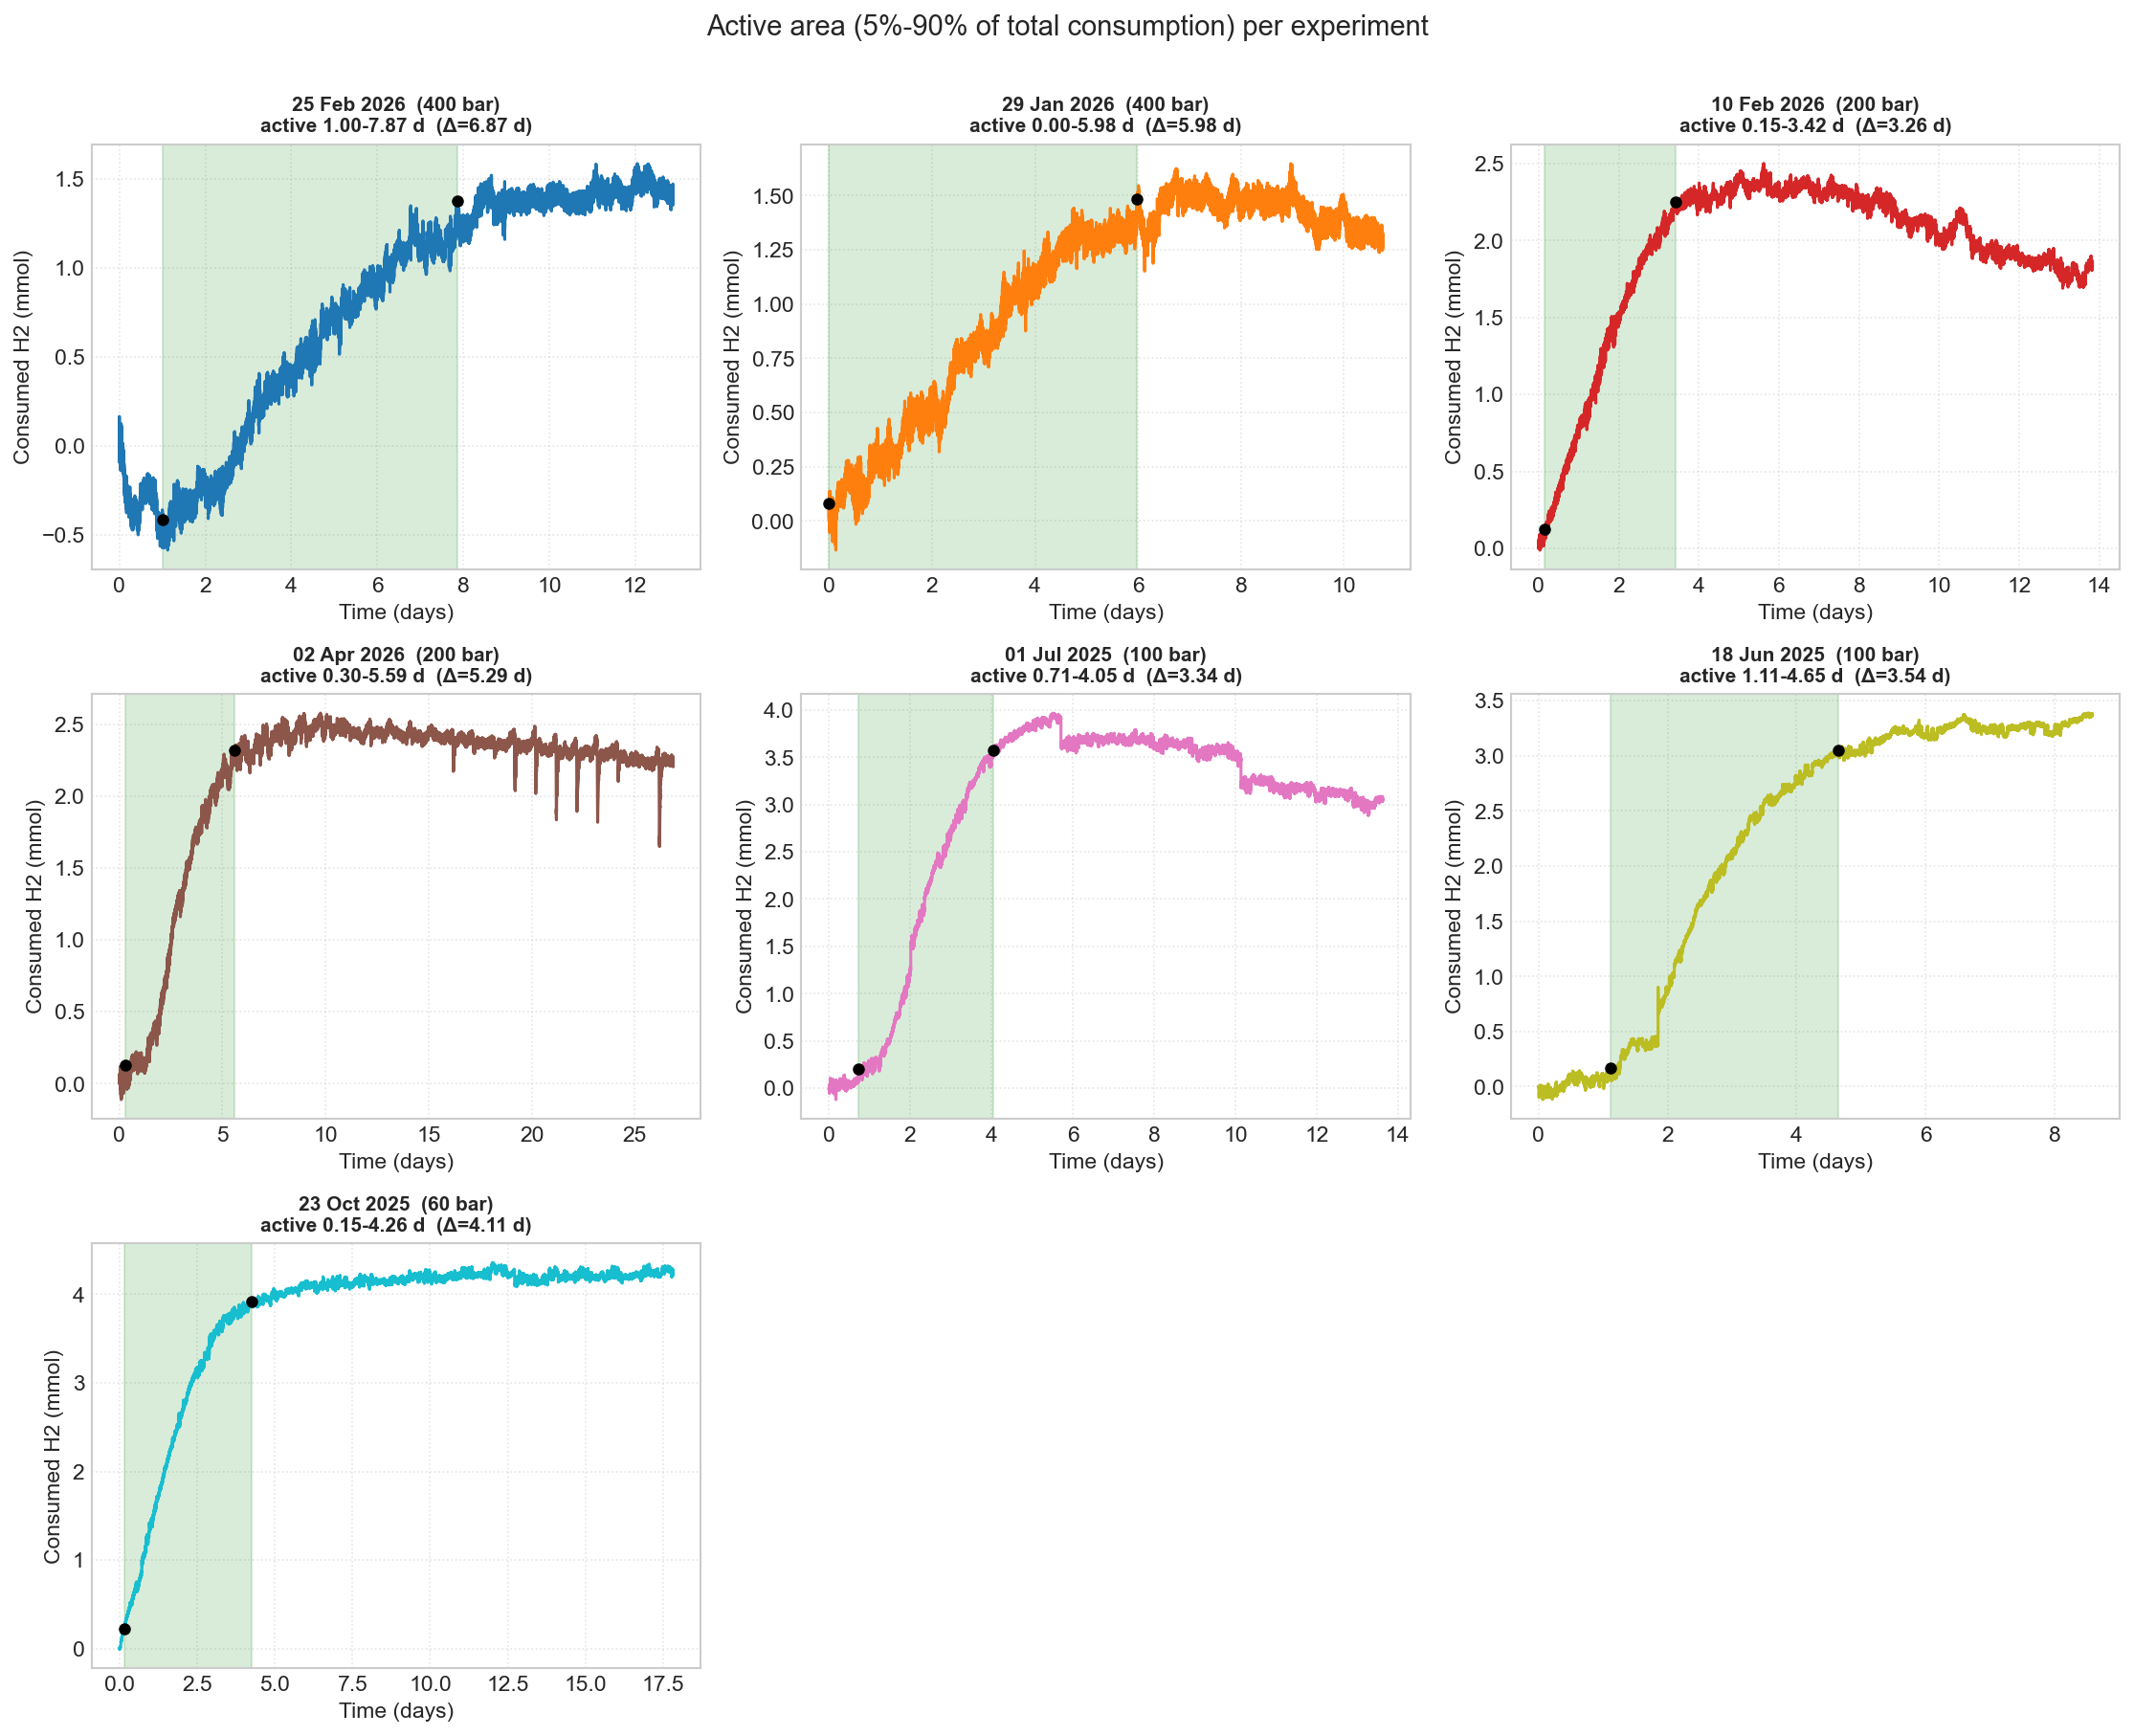

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def time_to_fraction(t_days, consumed, frac, t_ignore_before=0.0):
    """Time (days) until consumed reaches `frac` of the total rise (baseline -> peak),
    counting only upward progress. Points before `t_ignore_before` (days) are excluded
    from the search for the baseline and the rise, but stay in the data otherwise."""
    t = np.asarray(t_days, float)
    y = np.asarray(consumed, float)
    use = t >= t_ignore_before
    t = t[use]; y = y[use]
    if len(y) < 2:
        return np.nan
    i_peak = int(np.argmax(y))
    total = y[i_peak] - y[0]
    if total <= 0:
        return np.nan
    y_pos = np.maximum.accumulate(y[:i_peak + 1])   # positive-slope-only envelope
    target = y[0] + frac * total
    idx = int(np.argmax(y_pos >= target))
    if idx == 0:
        return 0.0
    y0, y1, t0, t1 = y_pos[idx-1], y_pos[idx], t[idx-1], t[idx]
    tc = t0 if y1 == y0 else t0 + (target - y0) * (t1 - t0) / (y1 - y0)
    return float(tc - t[0])


def fraction_crossing(t_days, consumed, frac, t_ignore_before=0.0):
    t = np.asarray(t_days, float); y = np.asarray(consumed, float)
    use = t >= t_ignore_before
    t = t[use]; y = y[use]
    if len(y) < 2:
        return np.nan, np.nan
    i_peak = int(np.argmax(y)); total = y[i_peak] - y[0]
    if total <= 0:
        return np.nan, np.nan
    y_pos = np.maximum.accumulate(y[:i_peak + 1])    # positive-slope-only envelope
    target = y[0] + frac * total
    idx = int(np.argmax(y_pos >= target))
    if idx == 0:
        return float(t[0]), float(y[0])
    y0, y1, t0, t1 = y_pos[idx-1], y_pos[idx], t[idx-1], t[idx]
    tc = t0 if y1 == y0 else t0 + (target - y0) * (t1 - t0) / (y1 - y0)
    return float(tc), float(target)


# (label, pressure, time[min], biotic mmol, sterile mmol, ignore_before_days)
# Only the 25 Feb 2026 (400 bar) run ignores its first day in the start search.
experiments = [
    ("25 Feb 2026", 400, time_26_02_25_clean, mmol1_26_02_25, mmol2_26_02_25, 1.0),
    ("29 Jan 2026", 400, time_26_01_29_clean, mmol1_26_01_29, mmol2_26_01_29, 0.0),
    ("10 Feb 2026", 200, time_26_02_10_clean, mmol1_26_02_10, mmol2_26_02_10, 0.0),
    ("02 Apr 2026", 200, time_26_04_02_clean, mmol1_26_04_02, mmol2_26_04_02, 0.0),
    ("01 Jul 2025", 100, time_25_07_01_clean, mmol1_25_07_01, mmol2_25_07_01, 0.0),
    ("18 Jun 2025", 100, time_25_06_18_clean, mmol1_25_06_18, mmol2_25_06_18, 0.0),
    ("23 Oct 2025",  60, time_25_10_23_clean, mmol1_25_10_23, mmol2_25_10_23, 0.0),
]

# one distinct colour per experiment
colors = plt.cm.tab10(np.linspace(0, 1, len(experiments)))

rows = []
for label, P, t_min, m1, m2, ignore in experiments:
    consumed = np.asarray(m1, float) - np.asarray(m2, float)   # biotic - sterile
    consumed = consumed - consumed[0]                          # start at zero
    t_days = np.asarray(t_min, float) / 1440.0                 # minutes -> days
    rows.append({
        "experiment": label,
        "pressure (bar)": P,
        "t to 5% (days)":  time_to_fraction(t_days, consumed, 0.05, ignore),
        "t to 90% (days)": time_to_fraction(t_days, consumed, 0.90, ignore),
    })

times_df = pd.DataFrame(rows)
display(times_df)

ncols = 3
nrows = int(np.ceil(len(experiments) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for ax, (label, P, t_min, m1, m2, ignore), color in zip(axes, experiments, colors):
    consumed = np.asarray(m1, float) - np.asarray(m2, float)
    consumed = consumed - consumed[0]
    t_days = np.asarray(t_min, float) / 1440.0
    t5,  y5  = fraction_crossing(t_days, consumed, 0.05, ignore)
    t90, y90 = fraction_crossing(t_days, consumed, 0.90, ignore)

    # full curve stays visible, including any ignored early data
    ax.plot(t_days, consumed, color=color, lw=1.5)


    if np.isfinite(t5) and np.isfinite(t90):
        ax.axvspan(t5, t90, color="green", alpha=0.15)
        ax.scatter([t5, t90], [y5, y90], color="black", zorder=5, s=25)
        ax.set_title(f"{label}  ({P} bar)\nactive {t5:.2f}-{t90:.2f} d  (Δ={t90-t5:.2f} d)", fontsize=10)
    else:
        ax.set_title(f"{label} ({P} bar) - no net consumption", fontsize=10)
    ax.set_xlabel("Time (days)"); ax.set_ylabel("Consumed H2 (mmol)")
    ax.grid(True, ls=":", alpha=0.5)

for ax in axes[len(experiments):]:   # hide unused panels
    ax.axis("off")
fig.suptitle("Active area (5%-90% of total consumption) per experiment", fontsize=14, y=1.005)
fig.tight_layout()
plt.show()